In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from keras import layers
from keras.models import Model
from keras.layers import (Conv2D, MaxPooling2D, BatchNormalization, Input, Activation)
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, Callback
from keras.preprocessing.image import load_img, img_to_array
from keras.optimizers import Adam
from keras.losses import categorical_crossentropy
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np
from PIL import Image

2025-07-04 06:35:56.062055: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751610956.262794      77 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751610956.326756      77 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
IMG_SIZE = (256, 256)
# ROOT_DIR = "../datasets/dataset_split"
ROOT_DIR = "/kaggle/input/turbine-blades-2/dataset_split"

In [3]:
# Mengambil nama-nama kelas dari direktori
CLASS_NAMES = ['ablation', 'breakdown', 'fracture', 'groove']

# Membuat mapping dari nama kelas ke indeks
CLASS_TO_INDEX = {name: index for index, name in enumerate(CLASS_NAMES)}

# Menghitung jumlah kelas
NUM_CLASSES = len(CLASS_NAMES) + 1

# Load data

In [4]:
def load_image_mask(image_path, mask_path):
    # Gambar dibaca, di-decode, dan di-resize (format PNG).
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    # Standardisasi ke rentang 0.0 - 1.0
    img = tf.cast(img, tf.float32) / 255.0

    # Mask dibaca, di-decode, dan di-resize.
    msk = tf.io.read_file(mask_path)
    msk = tf.image.decode_png(msk, channels=1)
    msk = tf.image.resize(msk, IMG_SIZE, method='nearest')
    msk = tf.cast(msk, tf.int32)  # pastikan integer
    
    # Ubah mask ke one-hot sesuai NUM_CLASSES
    msk = tf.squeeze(msk, axis=-1)
    msk = tf.one_hot(msk, depth=NUM_CLASSES)
    return img, msk

In [5]:
def augment_image_mask(img, mask, target_classes=None, crop_size=100, prob_crop=0.7, min_area=30):
    if target_classes is None:
        target_classes = [4]  # default ke groove
    mask_argmax = tf.argmax(mask, axis=-1)
    # Gabungkan semua mask target
    target_mask = tf.zeros_like(mask_argmax, dtype=tf.float32)
    for cls in target_classes:
        target_mask = tf.maximum(target_mask, tf.cast(tf.equal(mask_argmax, cls), tf.float32))
    target_area = tf.reduce_sum(target_mask)
    has_target = target_area > min_area

    do_crop = tf.logical_and(
        has_target,
        tf.less(tf.random.uniform([]), prob_crop)
    )

    def crop_patch():
        coords = tf.where(target_mask > 0)
        min_y = tf.reduce_min(coords[:, 0])
        max_y = tf.reduce_max(coords[:, 0])
        min_x = tf.reduce_min(coords[:, 1])
        max_x = tf.reduce_max(coords[:, 1])
        center_y = tf.cast((min_y + max_y) // 2, tf.int32)
        center_x = tf.cast((min_x + max_x) // 2, tf.int32)
        half = crop_size // 2
        offset_y = tf.random.uniform([], -half//2, half//2, dtype=tf.int32)
        offset_x = tf.random.uniform([], -half//2, half//2, dtype=tf.int32)
        center_y = tf.clip_by_value(center_y + offset_y, half, IMG_SIZE[0] - half)
        center_x = tf.clip_by_value(center_x + offset_x, half, IMG_SIZE[1] - half)
        start_y = tf.clip_by_value(center_y - half, 0, IMG_SIZE[0] - crop_size)
        start_x = tf.clip_by_value(center_x - half, 0, IMG_SIZE[1] - crop_size)
        img_patch = img[start_y:start_y+crop_size, start_x:start_x+crop_size, :]
        mask_patch = mask[start_y:start_y+crop_size, start_x:start_x+crop_size, :]
        img_resized = tf.image.resize(img_patch, IMG_SIZE, method='bilinear')
        mask_resized = tf.image.resize(mask_patch, IMG_SIZE, method='nearest')
        return img_resized, mask_resized

    img, mask = tf.cond(do_crop, crop_patch, lambda: (img, mask))
    
    # Random zoom (zoom in/out)
    def random_zoom(img, mask, min_zoom=0.8, max_zoom=1.2):
        zoom = tf.random.uniform([], min_zoom, max_zoom)
        new_size = tf.cast(tf.round(zoom * tf.cast(IMG_SIZE[0], tf.float32)), tf.int32)
        img_zoomed = tf.image.resize(img, [new_size, new_size], method='bilinear')
        mask_zoomed = tf.image.resize(mask, [new_size, new_size], method='nearest')
        # Center crop or pad to IMG_SIZE
        img_zoomed = tf.image.resize_with_crop_or_pad(img_zoomed, IMG_SIZE[0], IMG_SIZE[1])
        mask_zoomed = tf.image.resize_with_crop_or_pad(mask_zoomed, IMG_SIZE[0], IMG_SIZE[1])
        return img_zoomed, mask_zoomed

    if tf.random.uniform([]) > 0.5:
        img, mask = random_zoom(img, mask)
        
    # Tambahan: random rotation (khusus groove)
    def random_rotate(img, mask):
        k = tf.random.uniform([], 0, 4, dtype=tf.int32)
        img = tf.image.rot90(img, k)
        mask = tf.image.rot90(mask, k)
        return img, mask

    if tf.reduce_any(target_mask > 0) and tf.random.uniform([]) > 0.5:
        img, mask = random_rotate(img, mask)

    # Tambahan: elastic deformation (hanya jika groove, opsional, simple version)
    def elastic_deform(img, mask, alpha=10, sigma=4):
        # NOTE: tf implementation is limited, for full elastic use numpy/scipy offline
        # Here, just add small random displacement as a simple proxy
        dx = tf.random.normal([IMG_SIZE[0], IMG_SIZE[1], 1], 0, sigma) * alpha / IMG_SIZE[0]
        dy = tf.random.normal([IMG_SIZE[0], IMG_SIZE[1], 1], 0, sigma) * alpha / IMG_SIZE[1]
        grid_x, grid_y = tf.meshgrid(tf.range(IMG_SIZE[1]), tf.range(IMG_SIZE[0]))
        grid_x = tf.cast(grid_x, tf.float32) + dx[..., 0]
        grid_y = tf.cast(grid_y, tf.float32) + dy[..., 0]
        grid = tf.stack([grid_y, grid_x], axis=-1)
        img = tf.expand_dims(img, 0)
        mask = tf.expand_dims(mask, 0)
        img_deformed = tf.keras.layers.Resizing(IMG_SIZE[0], IMG_SIZE[1], interpolation="bilinear")(img)
        mask_deformed = tf.keras.layers.Resizing(IMG_SIZE[0], IMG_SIZE[1], interpolation="nearest")(mask)
        return img_deformed[0], mask_deformed[0]

    if tf.reduce_any(target_mask > 0) and tf.random.uniform([]) > 0.7:
        img, mask = elastic_deform(img, mask)
    
    # Augmentasi tambahan (aman untuk groove)
    if tf.random.uniform([]) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform([]) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    if tf.random.uniform([]) > 0.7:
        noise = tf.random.normal(shape=tf.shape(img), mean=0.0, stddev=0.03)
        img = tf.clip_by_value(img + noise, 0.0, 1.0)
    
    return img, mask

In [6]:
def get_oversampled_dataset(split_dir, batch_size=8, shuffle=True, augment=False, oversample_factor=3, oversample_classes=None):
    
    img_dir = os.path.join(split_dir, 'images')
    mask_dir = os.path.join(split_dir, 'masks')
    
    img_files = set([
        f for f in os.listdir(img_dir)
        if not (f.startswith('.') or f.startswith('._')) and f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])
    
    mask_files = set([
        f for f in os.listdir(mask_dir)
        if not (f.startswith('.') or f.startswith('._')) and f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])
    
    common_files = sorted(list(img_files & mask_files))
    
    img_paths = [os.path.join(img_dir, f) for f in common_files]
    mask_paths = [os.path.join(mask_dir, f) for f in common_files]

    # Pilih kelas minoritas yang ingin di-oversample
    if oversample_classes is None:
        oversample_classes = [4]

    # Deteksi file yang mengandung kelas minoritas
    minority_img_paths = []
    minority_mask_paths = []
    
    for img_path, mask_path in zip(img_paths, mask_paths):
        mask = tf.io.read_file(mask_path)
        mask = tf.image.decode_image(mask, channels=1)
        mask = tf.squeeze(mask, axis=-1)
        
        if any([tf.reduce_any(mask == c) for c in oversample_classes]):
            minority_img_paths.append(img_path)
            minority_mask_paths.append(mask_path)

    # Oversampling: duplikasi file minoritas
    img_paths_extended = img_paths + minority_img_paths * (oversample_factor - 1)
    mask_paths_extended = mask_paths + minority_mask_paths * (oversample_factor - 1)

    print(f"Jumlah data asli: {len(img_paths)}, setelah oversampling: {len(img_paths_extended)}")

    dataset = tf.data.Dataset.from_tensor_slices((img_paths_extended, mask_paths_extended))
    dataset = dataset.map(load_image_mask, num_parallel_calls=tf.data.AUTOTUNE)
    
    if augment:
        dataset = dataset.map(lambda img, mask: augment_image_mask(img, mask, target_classes=oversample_classes), num_parallel_calls=tf.data.AUTOTUNE)
        
    if shuffle:
        dataset = dataset.shuffle(200, seed=42)
        
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

### Lama get_dataset

In [7]:
# def get_dataset(split_dir, batch_size=8, shuffle=True):
#     img_dir = os.path.join(split_dir, 'images')
#     mask_dir = os.path.join(split_dir, 'masks')
    
#     img_files = set([
#         f for f in os.listdir(img_dir)
#         if not (f.startswith('.') or f.startswith('._')) and f.lower().endswith(('.png', '.jpg', '.jpeg'))
#     ])
#     mask_files = set([
#         f for f in os.listdir(mask_dir)
#         if not (f.startswith('.') or f.startswith('._')) and f.lower().endswith(('.png', '.jpg', '.jpeg'))
#     ])
    
#     common_files = sorted(list(img_files & mask_files))
#     img_paths = [os.path.join(img_dir, f) for f in common_files]
#     mask_paths = [os.path.join(mask_dir, f) for f in common_files]
#     print(f"Jumlah data di {split_dir}: {len(img_paths)}")
    
#     assert len(img_paths) == len(mask_paths), f"Jumlah gambar ({len(img_paths)}) dan mask ({len(mask_paths)}) tidak sama!"
#     dataset = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
#     dataset = dataset.map(load_image_mask, num_parallel_calls=tf.data.AUTOTUNE)
    
#     if shuffle:
#         dataset = dataset.shuffle(100, seed=42)
#     return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [8]:
# # Load dataset
# train_ds = get_dataset(f'{ROOT_DIR}/train', batch_size=8,shuffle=True)
# val_ds = get_dataset(f'{ROOT_DIR}/val', batch_size=8, shuffle=False)
# test_ds = get_dataset(f'{ROOT_DIR}/test', batch_size=8, shuffle=False)

In [9]:
# Load dataset
train_ds = get_oversampled_dataset(f'{ROOT_DIR}/aug-train', batch_size=8, augment=False, oversample_classes=[1, 2, 3, 4], oversample_factor=1)
val_ds = get_oversampled_dataset(f'{ROOT_DIR}/val', batch_size=8, augment=False, oversample_factor=1)
test_ds = get_oversampled_dataset(f'{ROOT_DIR}/test', batch_size=8, augment=False, oversample_factor=1)

I0000 00:00:1751610974.666151      77 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Jumlah data asli: 3240, setelah oversampling: 3240
Jumlah data asli: 227, setelah oversampling: 227
Jumlah data asli: 112, setelah oversampling: 112


# Arsitektur

## U-Net

In [50]:
def conv_block(input_tensor, num_filters):
    """Blok konvolusi ganda yang menjadi dasar U-Net."""
    # Lapisan konvolusi pertama
    x = Conv2D(num_filters, (3, 3), padding="same")(input_tensor)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    
    # Lapisan konvolusi kedua
    x = Conv2D(num_filters, (3, 3), padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    return x

def unet(input_size=(256, 256, 3), num_classes=NUM_CLASSES):
    inputs = Input(input_size)  

    # --- ENCODER (JALUR KONTRAKSI) ---
    # Blok 1
    s1 = conv_block(inputs, 64)
    p1 = layers.MaxPooling2D((2, 2))(s1)
    
    # Blok 2
    s2 = conv_block(p1, 128)
    p2 = layers.MaxPooling2D((2, 2))(s2)

    # Blok 3
    s3 = conv_block(p2, 256)
    p3 = layers.MaxPooling2D((2, 2))(s3)

    # Blok 4
    s4 = conv_block(p3, 512)
    p4 = layers.MaxPooling2D((2, 2))(s4)

    # --- BOTTLENECK ---
    b1 = conv_block(p4, 1024)

    # --- DECODER (JALUR EKSPANSI) ---
    # Blok 6
    u6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding="same")(b1)
    # Menggabungkan dengan skip connection dari Blok 4 Encoder
    c6 = layers.concatenate([u6, s4])
    s6 = conv_block(c6, 512)
    
    # Blok 7
    u7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding="same")(s6)
    # Menggabungkan dengan skip connection dari Blok 3 Encoder
    c7 = layers.concatenate([u7, s3])
    s7 = conv_block(c7, 256)

    # Blok 8
    u8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding="same")(s7)
    # Menggabungkan dengan skip connection dari Blok 2 Encoder
    c8 = layers.concatenate([u8, s2])
    s8 = conv_block(c8, 128)
    
    # Blok 9
    u9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(s8)
    # Menggabungkan dengan skip connection dari Blok 1 Encoder
    c9 = layers.concatenate([u9, s1])
    s9 = conv_block(c9, 64)

    conv10 = Conv2D(num_classes, (1, 1), activation='softmax')(s9)

    return Model(inputs=[inputs], outputs=[conv10], name='UNet')

## Recurrent U-Net

In [11]:
def se_block(input_tensor, reduction=16):
    """Squeeze-and-Excitation Block."""
    filters = input_tensor.shape[-1]
    se = layers.GlobalAveragePooling2D()(input_tensor)
    se = layers.Dense(filters // reduction, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, filters))(se)
    return layers.Multiply()([input_tensor, se])

In [12]:
def recurrent_conv_block(inputs, filters, kernel_size=(3, 3), t=2, dropout_rate=0.2, use_se=True):
    """Recurrent Convolution Block with residual connection, dropout, and optional SE block."""
    x = Conv2D(filters, kernel_size, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    residual = x
    for i in range(t):
        x = Conv2D(filters, kernel_size, padding='same')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)

    x = layers.Add()([x, residual])
    x = layers.SpatialDropout2D(dropout_rate)(x)
    if use_se:
        x = se_block(x)
    return x

In [13]:
def rec_unet(input_size=(256, 256, 3), t=2, num_classes=NUM_CLASSES):
    inputs = Input(input_size)

    # Encoder
    conv1 = recurrent_conv_block(inputs, 32, t=t)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = recurrent_conv_block(pool1, 64, t=t)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = recurrent_conv_block(pool2, 128, t=t)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = recurrent_conv_block(pool3, 256, t=t)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

    # Middle
    conv5 = recurrent_conv_block(pool4, 512, t=t)

    # Decoder
    up6 = layers.concatenate([layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(conv5), conv4], axis=3)
    conv6 = recurrent_conv_block(up6, 256, t=t)

    up7 = layers.concatenate([layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv6), conv3], axis=3)
    conv7 = recurrent_conv_block(up7, 128, t=t)

    up8 = layers.concatenate([layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv7), conv2], axis=3)
    conv8 = recurrent_conv_block(up8, 64, t=t)

    up9 = layers.concatenate([layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(conv8), conv1], axis=3)
    conv9 = recurrent_conv_block(up9, 32, t=t)

    conv10 = Conv2D(num_classes, (1, 1), activation='softmax')(conv9)

    return Model(inputs=[inputs], outputs=[conv10], name='rec_unet')

## Transformer U-Net

In [14]:
def cnn_encoder(x):
    skips = []

    # Block 1
    x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
    skips.append(x)
    x = MaxPooling2D((2,2))(x)

    # Block 2
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    skips.append(x)
    x = MaxPooling2D((2,2))(x)

    # Block 3
    x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
    skips.append(x)
    x = MaxPooling2D((2,2))(x)

    # Block 4
    x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
    x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
    skips.append(x)
    x = MaxPooling2D((2,2))(x)  # Output: 16x16 if input 256x256

    return x, skips

def patch_embedding(x, projection_dim=512):
    # x shape: [B, H, W, C]
    patches = Conv2D(projection_dim, kernel_size=1, strides=1, padding='same')(x)
    H, W, D = patches.shape[1], patches.shape[2], patches.shape[3]
    flat = layers.Reshape((H * W, D))(patches)
    return flat, (H, W, D)

def transformer_encoder(x, num_layers=4, num_heads=4, ff_dim=512):
    for _ in range(num_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(x)
        attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=x.shape[-1] // num_heads)(x1, x1)
        x = x + attn_output

        x2 = layers.LayerNormalization(epsilon=1e-6)(x)
        ffn_output = layers.Dense(ff_dim, activation='relu')(x2)
        ffn_output = layers.Dense(x.shape[-1])(ffn_output)
        x = x + ffn_output
    return x

def transformer_unet(input_size=(256, 256, 3), num_classes=NUM_CLASSES):
    inputs = Input(shape=input_size)

    # CNN Encoder
    cnn_encoded, skips = cnn_encoder(inputs)

    # Transformer Block
    x_flat, (H, W, D) = patch_embedding(cnn_encoded)
    transformer_out = transformer_encoder(x_flat, num_layers=4, num_heads=4, ff_dim=1024)
    x = layers.Reshape((H, W, D))(transformer_out)

    # Decoder
    up4 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(x)
    concat4 = layers.concatenate([up4, skips[3]])
    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(concat4)
    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv4)

    up3 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv4)
    concat3 = layers.concatenate([up3, skips[2]])
    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(concat3)
    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv3)

    up2 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv3)
    concat2 = layers.concatenate([up2, skips[1]])
    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(concat2)
    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv2)

    up1 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(conv2)
    concat1 = layers.concatenate([up1, skips[0]])
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(concat1)
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv1)

    outputs = Conv2D(num_classes, (1, 1), activation='softmax')(conv1)

    return Model(inputs, outputs, name="Transformer_UNet")


## Transformer Recurrent U-Net

In [15]:
def recurrent_block(x, filters, t=2):
    for i in range(t):
        if i == 0:
            x1 = Conv2D(filters, kernel_size=3, padding='same', activation='relu')(x)
        else:
            x1 = Conv2D(filters, kernel_size=3, padding='same', activation='relu')(layers.Add()([x, x1]))
            x1 = BatchNormalization()(x1)
    return x1

In [16]:

def rcnn_block(x, filters, t=2):
    x1 = recurrent_block(x, filters, t)
    x2 = recurrent_block(x1, filters, t)
    out = layers.Add()([x, x2])
    return out

In [17]:
def transformer_block(x, num_heads=4, ff_dim=512):
    B, H, W, C = x.shape
    x_flat = layers.Reshape((H * W, C))(x)

    # LayerNorm + MHA
    attn_input = layers.LayerNormalization(epsilon=1e-6)(x_flat)
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=C // num_heads)(attn_input, attn_input)
    x = x_flat + attn_output  # Residual connection

    # FFN
    ffn_input = layers.LayerNormalization(epsilon=1e-6)(x)
    ffn_output = layers.Dense(ff_dim, activation='relu')(ffn_input)
    ffn_output = layers.Dense(C)(ffn_output)
    x = x + ffn_output  # Residual connection

    return layers.Reshape((H, W, C))(x)

In [18]:
def rec_transunet_with_rcnn(input_size=(256, 256, 3), num_classes=NUM_CLASSES, num_heads=4, ff_dim=512):
    inputs = Input(input_size)
    
    # Encoder
    conv1 = rcnn_block(inputs, 32)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = rcnn_block(pool1, 64)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = rcnn_block(pool2, 128)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = rcnn_block(pool3, 256)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

    # Bottleneck with Transformer
    conv5 = rcnn_block(pool4, 512)
    trans = transformer_block(conv5, num_heads=num_heads, ff_dim=ff_dim)

    # Decoder
    up6 = layers.concatenate([layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(trans), conv4], axis=-1)
    conv6 = rcnn_block(up6, 256)

    up7 = layers.concatenate([layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv6), conv3], axis=-1)
    conv7 = rcnn_block(up7, 128)

    up8 = layers.concatenate([layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv7), conv2], axis=-1)
    conv8 = rcnn_block(up8, 64)

    up9 = layers.concatenate([layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(conv8), conv1], axis=-1)
    conv9 = rcnn_block(up9, 32)

    outputs = Conv2D(num_classes, (1, 1), activation='softmax')(conv9)

    return Model(inputs=inputs, outputs=outputs, name="Transunet_RCL")

## Transunet Recurrent (Pretrained Resnet50)

In [19]:
def recurrent_block(x, filters, t=2, dropout_rate=0.5):
    for i in range(t):
        if i == 0:
            x1 = layers.Conv2D(filters, kernel_size=3, padding='same', activation='relu')(x)
            # x1 = layers.Dropout(dropout_rate)(x1)  # Dropout ditambahkan setelah Conv2D pertama
        else:
            x1 = layers.Conv2D(filters, kernel_size=3, padding='same', activation='relu')(layers.Add()([x, x1]))
            x1 = layers.BatchNormalization()(x1)
            # x1 = layers.Dropout(dropout_rate)(x1)  # Dropout ditambahkan setelah BatchNorm
            return x1

def rcnn_block(x, filters, t=2):
    if x.shape[-1] != filters:
        x = Conv2D(filters, kernel_size=1, padding='same')(x)
    x1 = recurrent_block(x, filters, t)
    x2 = recurrent_block(x1, filters, t)
    return layers.Add()([x, x2])


def transformer_block(x, num_heads=4, ff_dim=512):
    B, H, W, C = x.shape
    x_flat = layers.Reshape((H * W, C))(x)
    
    # LayerNorm + MHA
    attn_input = layers.LayerNormalization(epsilon=1e-6)(x_flat)
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=C // num_heads)(attn_input, attn_input)
    x = x_flat + attn_output  # Residual connection

    # FFN   
    ffn_input = layers.LayerNormalization(epsilon=1e-6)(x)
    ffn_output = layers.Dense(ff_dim, activation='relu')(ffn_input)
    ffn_output = layers.Dense(C)(ffn_output)
    x = x + ffn_output  # Residual connection

    return layers.Reshape((H, W, C))(x)

In [20]:
def resnet_transunet_with_rcnn(input_size=(256, 256, 3), num_classes=NUM_CLASSES, backbone_type='Resnet50', num_heads=4, ff_dim=512):
    inputs = Input(input_size)
    
     # Pretrained Encoder (ResNet50)
    base_model = ResNet50(include_top=False, weights='imagenet', input_tensor=inputs)

      # Ambil skip connections dari ResNet50
    skips = [
        base_model.get_layer("conv2_block3_out").output,  # 64×64
        base_model.get_layer("conv3_block4_out").output,  # 32×32
        base_model.get_layer("conv4_block6_out").output,  # 16×16
    ]
    
    encoder_output = base_model.get_layer("conv5_block3_out").output  # 8×8

    # Transformer Bottleneck
    trans = transformer_block(encoder_output, num_heads=num_heads, ff_dim=ff_dim)

    # Upsample dari bottleneck (8x8 → 16x16)
    d1 = layers.Conv2DTranspose(320, (2, 2), strides=(2, 2), padding='same')(trans)
    # skip connection dgn resolusi sama (~16x16): block4a_activation
    d1 = layers.concatenate([d1, skips[2]])  # gunakan skips[2] untuk resolusi 16x16
    d1 = rcnn_block(d1, 320)

    # Lanjut ke upsampling berikutnya
    d2 = layers.Conv2DTranspose(192, (2, 2), strides=(2, 2), padding='same')(d1)
    d2 = layers.concatenate([d2, skips[1]])  # ~32x32
    d2 = rcnn_block(d2, 192)

    d3 = layers.Conv2DTranspose(96, (2, 2), strides=(2, 2), padding='same')(d2)
    d3 = layers.concatenate([d3, skips[0]])  # ~64x64
    d3 = rcnn_block(d3, 96)

    # Tambahkan upsampling terakhir jika ingin output ke ukuran asli (256x256)
    d4 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(d3)
    d4 = rcnn_block(d4, 32)

    # Tambahkan upsampling terakhir untuk 128x128 → 256x256
    d5 = layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(d4)
    d5 = rcnn_block(d5, 16)

    outputs = Conv2D(num_classes, (1, 1), activation='softmax')(d5)

    return Model(inputs=inputs, outputs=outputs, name="Transunet")

# Metrix dan Callback

## Callback

In [21]:
earlystopping = EarlyStopping(monitor='val_dsc', patience=10, mode='max',
                              verbose=1, restore_best_weights=True, min_delta=1e-6)

reduce_lr = ReduceLROnPlateau(monitor='val_dsc', factor=0.5, patience=3, mode='max', verbose=2)

transunet_checkpoint = ModelCheckpoint(
    filepath='model/transunet.keras',
    monitor='val_dsc',
    mode='max',
    save_best_only=True,
    verbose=1
)

## Metrix

In [22]:
NUM_CLASSES = 5
IMG_SIZE = (256, 256)  # atau sesuai ukuran kamu
EPOCHS = 100

### IOU

In [23]:
def iou(y_true, y_pred, smooth=1e-7):
    y_true_f = tf.reshape(y_true, [-1, tf.shape(y_true)[-1]])
    y_pred_f = tf.reshape(y_pred, [-1, tf.shape(y_pred)[-1]])

    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=0)
    union = tf.reduce_sum(y_true_f + y_pred_f, axis=0) - intersection

    iou = (intersection + smooth) / (union + smooth)
    return tf.reduce_mean(iou)

In [24]:
def miou(y_true, y_pred, num_classes=NUM_CLASSES, smooth=1e-6):
    # # y_true, y_pred: (batch, H, W, C)
    # y_pred = tf.cast(y_pred > threshold, tf.float32)
    # y_true = tf.cast(y_true, tf.float32)
    # intersection = tf.reduce_sum(y_true * y_pred, axis=[0,1,2])
    # union = tf.reduce_sum(y_true + y_pred, axis=[0,1,2]) - intersection
    # iou = (intersection + smooth) / (union + smooth)
    # return tf.reduce_mean(iou)
    
    y_pred = tf.argmax(y_pred, axis=-1)
    y_true = tf.argmax(y_true, axis=-1)
    
    miou = 0
    for i in range(num_classes):
        true_class = tf.cast(tf.equal(y_true, i), tf.float32)
        pred_class = tf.cast(tf.equal(y_pred, i), tf.float32)
        intersection = tf.reduce_sum(tf.multiply(true_class, pred_class))
        union = tf.reduce_sum(true_class) + tf.reduce_sum(pred_class) - intersection
        iou = (intersection + smooth) / (union + smooth)
        miou += iou
    return miou / num_classes

### Dice Coef

In [25]:
def dsc(y_true, y_pred, smooth=1e-6):
    """
    Multi-class Dice Coefficient.
    y_true, y_pred: shape (batch, H, W, C), one-hot encoded.
    """
    # y_true = tf.cast(y_true, tf.float32)
    # y_pred = tf.cast(y_pred, tf.float32)
    
    # intersection = tf.reduce_sum(y_true * y_pred, axis=[0, 1, 2])
    # union = tf.reduce_sum(y_true + y_pred, axis=[0, 1, 2])
    
    # dice = (2. * intersection + smooth) / (union + smooth)
    # return tf.reduce_mean(dice)
    
    y_pred = tf.argmax(y_pred, axis=-1)
    y_true = tf.argmax(y_true, axis=-1)
    dice = 0
    for i in range(NUM_CLASSES):
        true_class = tf.cast(tf.equal(y_true, i), tf.float32)
        pred_class = tf.cast(tf.equal(y_pred, i), tf.float32)
        intersection = tf.reduce_sum(true_class * pred_class)
        union = tf.reduce_sum(true_class) + tf.reduce_sum(pred_class)
        dice += (2. * intersection + smooth) / (union + smooth)
    return dice / NUM_CLASSES

### Dice loss

In [26]:
def dice_loss(y_true, y_pred):
    loss = 1 - dsc(y_true, y_pred)
    return loss

### BCE loss

In [27]:
def bce_dice_loss(y_true, y_pred):
    loss = categorical_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)
    return loss

### Tversky loss

In [28]:
def tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3):
    y_true_pos =  tf.keras.backend.flatten(y_true)
    y_pred_pos =  tf.keras.backend.flatten(y_pred)
    true_pos =  tf.keras.backend.sum(y_true_pos * y_pred_pos)
    false_neg =  tf.keras.backend.sum(y_true_pos * (1 - y_pred_pos))
    false_pos =  tf.keras.backend.sum((1 - y_true_pos) * y_pred_pos)
    return 1 - (true_pos + 1e-6) / (true_pos + alpha * false_neg + beta * false_pos + 1e-6)


### Weigted + Dice loss

In [29]:
def weighted_categorical_crossentropy(weights):
    weights = tf.constant(weights, dtype=tf.float32)

    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)  # untuk menghindari log(0)
        loss = y_true * tf.math.log(y_pred) * weights
        return -tf.reduce_mean(tf.reduce_sum(loss, axis=-1))
    
    return loss

def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    union = tf.reduce_sum(y_true + y_pred, axis=[1, 2, 3])
    dice = (2. * intersection + smooth) / (union + smooth)
    
    return 1 - tf.reduce_mean(dice)

def combined_loss(weights, alpha=0.5):
    """
    weights: list of class weights (e.g., [0.1, 2.0, 2.5, 3.0, 4.0])
    alpha: balance factor between crossentropy and dice loss
    """
    wce = weighted_categorical_crossentropy(weights)

    def loss(y_true, y_pred):
        return alpha * wce(y_true, y_pred) + (1 - alpha) * dice_loss(y_true, y_pred)
    
    return loss

### Focal loss

In [30]:
def focal_tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3, gamma=0.75, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    tp = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    fn = tf.reduce_sum(y_true * (1 - y_pred), axis=[1,2,3])
    fp = tf.reduce_sum((1 - y_true) * y_pred, axis=[1,2,3])
    
    tversky = (tp + smooth) / (tp + alpha*fn + beta*fp + smooth)
    return tf.reduce_mean(tf.pow((1 - tversky), gamma))

### Focal tversky + weighted loss

In [31]:
loss = lambda y_true, y_pred: 0.4 * weighted_categorical_crossentropy(CLASS_WEIGHTS)(y_true, y_pred) + 0.6 * focal_tversky_loss(y_true, y_pred)

### Calculate class weight

In [32]:
def compute_class_weights(mask_paths, num_classes, ignore_background=True):
    pixel_counts = np.zeros(num_classes)
    for mask_path in mask_paths:
        mask = np.array(load_img(mask_path, color_mode="grayscale"))
        for c in range(num_classes):
            pixel_counts[c] += np.sum(mask == c)
    total = np.sum(pixel_counts)
    class_weights = total / (num_classes * pixel_counts + 1e-6)
    class_weights = class_weights / np.mean(class_weights)
    if ignore_background:
        class_weights[0] = 1.0  # atau 0.5, sesuai kebutuhan
    return class_weights

In [33]:
# ...existing code...
mask_path_train = os.path.join(ROOT_DIR, 'train', 'masks')
mask_files = [os.path.join(mask_path_train, f) for f in os.listdir(mask_path_train) if f.endswith('.png') or f.endswith('.jpg')]
class_weights = compute_class_weights(mask_files, 5)

# Jika ingin membatasi agar tidak timpang:
class_weights = np.clip(class_weights, 0.5, 5.0)  # batas min 0.5, max 5.0
print("Class weights:", class_weights)
# ...existing code...

Class weights: [1.         0.5        0.5        0.5        4.42531904]


In [34]:
CLASS_NAMES = ['background', 'ablation', 'breakdown', 'fracture', 'groove']

In [35]:
def pixel_distribution_per_class(split_dir, class_names=CLASS_NAMES):
    mask_dir = os.path.join(split_dir, 'masks')
    files = [f for f in os.listdir(mask_dir) if f.endswith('.png')]
    pixel_counts = np.zeros(len(class_names), dtype=np.int64)
    for f in files:
        mask = np.array(Image.open(os.path.join(mask_dir, f)))
        for i in range(len(class_names)):
            pixel_counts[i] += np.sum(mask == i)
    return pixel_counts

splits = ['aug-train', 'val', 'test']
data = []
for split in splits:
    counts = pixel_distribution_per_class(f'{ROOT_DIR}/{split}', class_names=CLASS_NAMES)
    row = dict(split=split)
    row.update({cname: count for cname, count in zip(CLASS_NAMES, counts)})
    data.append(row)

df = pd.DataFrame(data)
print(df)

       split  background  ablation  breakdown  fracture  groove
0  aug-train   210809996    827983     158481    526391   13789
1        val    14768109     63394      10651     33490    1028
2       test     7261504     50225       5391     22412     500


In [36]:
def foreground_background_distribution(split_dir):
    mask_dir = os.path.join(split_dir, 'masks')
    files = [f for f in os.listdir(mask_dir) if f.endswith('.png')]
    total_bg = 0
    total_fg = 0
    for f in files:
        mask = np.array(Image.open(os.path.join(mask_dir, f)))
        total_bg += np.sum(mask == 0)
        total_fg += np.sum(mask > 0)
    total = total_bg + total_fg
    bg_pct = 100 * total_bg / total if total > 0 else 0
    fg_pct = 100 * total_fg / total if total > 0 else 0
    print(f"{split_dir}: Background = {bg_pct:.2f}%, Foreground = {fg_pct:.2f}% (Total pixels: {total})")

for split in [f"{ROOT_DIR}/train", f"{ROOT_DIR}/val", f"{ROOT_DIR}/test"]:
    foreground_background_distribution(split)

/kaggle/input/turbine-blades-2/dataset_split/train: Background = 99.28%, Foreground = 0.72% (Total pixels: 53084160)
/kaggle/input/turbine-blades-2/dataset_split/val: Background = 99.27%, Foreground = 0.73% (Total pixels: 14876672)
/kaggle/input/turbine-blades-2/dataset_split/test: Background = 98.93%, Foreground = 1.07% (Total pixels: 7340032)


In [37]:
# aug-train
pixel_counts = np.array([210809996, 827983, 158481, 526391, 13789], dtype=np.float32)

#  train
# pixel_counts = np.array([52702419, 207072, 39623, 131600, 3446], dtype=np.float32)

# Log Inverse Frequency atau smoothed
log_counts = np.log(pixel_counts + 1e-6)
# Inverse frequency untuk memberi bobot lebih ke kelas minoritas
weights1 = 1.0 / log_counts
weights1 /= weights1.sum()  # Normalize agar total bobot = 1

print("Smoothed Weights:", weights1)

Smoothed Weights: [0.1338149  0.18821503 0.21420489 0.19468634 0.26907882]


In [38]:
def weighted_categorical_crossentropy(class_weights):
    class_weights = tf.constant(class_weights, dtype=tf.float32)
    def loss_fn(y_true, y_pred):
        # y_true dan y_pred: shape (batch, H, W, num_classes)
        loss = categorical_crossentropy(y_true, y_pred, from_logits=False)  # shape: (batch, H, W)
        weights_per_pixel = tf.reduce_sum(y_true * class_weights, axis=-1)  # shape: (batch, H, W)
        weighted_loss = loss * weights_per_pixel
        return tf.reduce_mean(weighted_loss)

    return loss_fn

# Compile model

In [39]:
model_unet = unet()
model_unet.compile(
    optimizer=Adam(learning_rate=1e-4),
    # loss=categorical_crossentropy,
    # loss=bce_dice_loss,
    # loss=loss_fn,
    # loss=combined_loss(ClASS_WEIGHTS, alpha=0.4),
    # loss=focal_tversky_loss,
    loss=weighted_categorical_crossentropy(weights1),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
        dsc,
        miou
    ]
)

In [ ]:
model_rec_unet = rec_unet()
model_rec_unet.compile(
    optimizer=Adam(learning_rate=1e-4),
    # loss=categorical_crossentropy,
    # loss=bce_dice_loss,
    # loss=loss_fn,
    loss=combined_loss(ClASS_WEIGHTS, alpha=0.4),
    # loss=focal_tversky_loss,
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
        dsc,
        iou
    ]
)

In [ ]:
model_transunet = transformer_unet()
model_transunet.compile(
    optimizer=Adam(learning_rate=1e-4),
    # loss=categorical_crossentropy,
    # loss=bce_dice_loss,
    # loss=loss_fn,
    loss=combined_loss(ClASS_WEIGHTS, alpha=0.4),
    # loss=focal_tversky_loss,
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
        dsc,
        iou
    ]
)

In [ ]:
model_rec_transunet = rec_transunet_with_rcnn(num_heads=4, ff_dim=1026)
model_rec_transunet.compile(
    optimizer=Adam(learning_rate=1e-4),
    # loss=categorical_crossentropy,
    # loss=bce_dice_loss,
    # loss=loss_fn,
    loss=combined_loss(ClASS_WEIGHTS, alpha=0.4),
    # loss=focal_tversky_loss,
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
        dsc,
        iou
    ]
)

In [ ]:
model_resnet_transunet = resnet_transunet_with_rcnn(num_heads=4, ff_dim=1026)
model_resnet_transunet.compile(
    optimizer=Adam(learning_rate=1e-4),
    # loss=categorical_crossentropy,
    # loss=bce_dice_loss,
    # loss=loss_fn,
    # loss=combined_loss(ClASS_WEIGHTS, alpha=0.4),
    # loss=focal_tversky_loss,
    loss=weighted_categorical_crossentropy(weights1),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
        dsc,
        miou
    ]
)

# Training

## Transformer Unet Recurrent

In [40]:
history_unet = model_unet.fit(train_ds, validation_data=val_ds,
                    epochs=EPOCHS, callbacks=[earlystopping, reduce_lr], verbose=1)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 256, 256, 3))
  warnings.warn(msg)
I0000 00:00:1751611102.151782     109 service.cc:148] XLA service 0x7f49ac003770 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1751611102.152664     109 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1751611103.893100     109 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1751611128.512273     109 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.7986 - dsc: 0.1844 - loss: 0.1094 - miou: 0.1748

E0000 00:00:1751611223.543443     109 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1751611223.798287     109 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


405/405 ━━━━━━━━━━━━━━━━━━━━ 145s 244ms/step - accuracy: 0.7989 - dsc: 0.1846 - loss: 0.1093 - miou: 0.1750 - val_accuracy: 0.9927 - val_dsc: 0.3165 - val_loss: 0.0317 - val_miou: 0.3157 - learning_rate: 1.0000e-04
Epoch 2/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 90s 221ms/step - accuracy: 0.9864 - dsc: 0.4595 - loss: 0.0282 - miou: 0.4580 - val_accuracy: 0.9927 - val_dsc: 0.3096 - val_loss: 0.0165 - val_miou: 0.3089 - learning_rate: 1.0000e-04
Epoch 3/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 90s 221ms/step - accuracy: 0.9864 - dsc: 0.6238 - loss: 0.0192 - miou: 0.6224 - val_accuracy: 0.9927 - val_dsc: 0.2889 - val_loss: 0.0122 - val_miou: 0.2881 - learning_rate: 1.0000e-04
Epoch 4/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 90s 222ms/step - accuracy: 0.9867 - dsc: 0.6525 - loss: 0.0156 - miou: 0.6511 - val_accuracy: 0.9927 - val_dsc: 0.3441 - val_loss: 0.0102 - val_miou: 0.3434 - learning_rate: 1.0000e-04
Epoch 5/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 90s 221ms/step - accuracy: 0.9868 - dsc: 0.6784 - loss: 0.0133 - m

In [ ]:
history_rec_unet = model_rec_unet.fit(train_ds, validation_data=val_ds,
                    epochs=EPOCHS, callbacks=[earlystopping, reduce_lr], verbose=1)

In [ ]:
history_rec_transunet = model_rec_transunet.fit(train_ds, validation_data=val_ds,
                    epochs=EPOCHS, callbacks=[earlystopping, reduce_lr], verbose=1)

In [ ]:
history_resnet_transunet = model_resnet_transunet.fit(train_ds, validation_data=val_ds,
                    epochs=EPOCHS, callbacks=[earlystopping, reduce_lr], verbose=1)

In [ ]:
history_transunet = model_transunet.fit(train_ds, validation_data=val_ds,
                    epochs=EPOCHS, callbacks=[earlystopping, reduce_lr], verbose=1)

# Tuning

In [ ]:
# Daftar kombinasi yang ingin diuji
num_heads_list = [2, 4, 8]
ff_dim_list = [256, 512, 1024]
EPOCHS_SHORT = 15  # Training singkat
results = []

In [ ]:
for num_heads in num_heads_list:
    for ff_dim in ff_dim_list:
        print(f"Training dengan num_heads={num_heads}, ff_dim={ff_dim}")
        
        # Modifikasi fungsi transunet_with_rcnn agar menerima parameter num_heads dan ff_dim
        model = transunet_with_rcnn(num_heads=num_heads, ff_dim=ff_dim)
        model.compile(
            optimizer=Adam(learning_rate=1e-4),
            loss=combined_loss(CLASS_WEIGHTS, alpha=0.4),
            metrics=[
                tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
                dsc,
                iou
            ]
        )
        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS_SHORT,
            callbacks=[earlystopping, reduce_lr],
            verbose=1
        )
        # Simpan hasil akhir val_dsc dan val_iou
        best_val_dsc = max(history.history['val_dsc'])
        best_val_iou = max(history.history['val_iou'])
        results.append({
            'num_heads': num_heads,
            'ff_dim': ff_dim,
            'best_val_dsc': best_val_dsc,
            'best_val_iou': best_val_iou
        })

In [ ]:
# Tampilkan hasil grid search
import pandas as pd
df_results = pd.DataFrame(results)
print(df_results.sort_values(by='best_val_dsc', ascending=False))

# Grafik Training

In [41]:
def plot_training_history(history, title="Training History"):
    plt.figure(figsize=(16, 10))

    # Plot Accuracy
    plt.subplot(2, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f"{title} - Accuracy")
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(2, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f"{title} - Loss")
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Dice Coefficient
    plt.subplot(2, 2, 3)
    plt.plot(history.history['dsc'], label='Train DSC')
    plt.plot(history.history['val_dsc'], label='Val DSC')
    plt.title(f"{title} - Dice Coefficient")
    plt.xlabel('Epochs')
    plt.ylabel('DSC')
    plt.legend()

    # Plot IoU
    plt.subplot(2, 2, 4)
    plt.plot(history.history['miou'], label='Train miou')
    plt.plot(history.history['val_miou'], label='Val miou')
    plt.title(f"{title} - Intersection over Union (miou)")
    plt.xlabel('Epochs')
    plt.ylabel('miou')
    plt.legend()

    plt.tight_layout()
    plt.show()

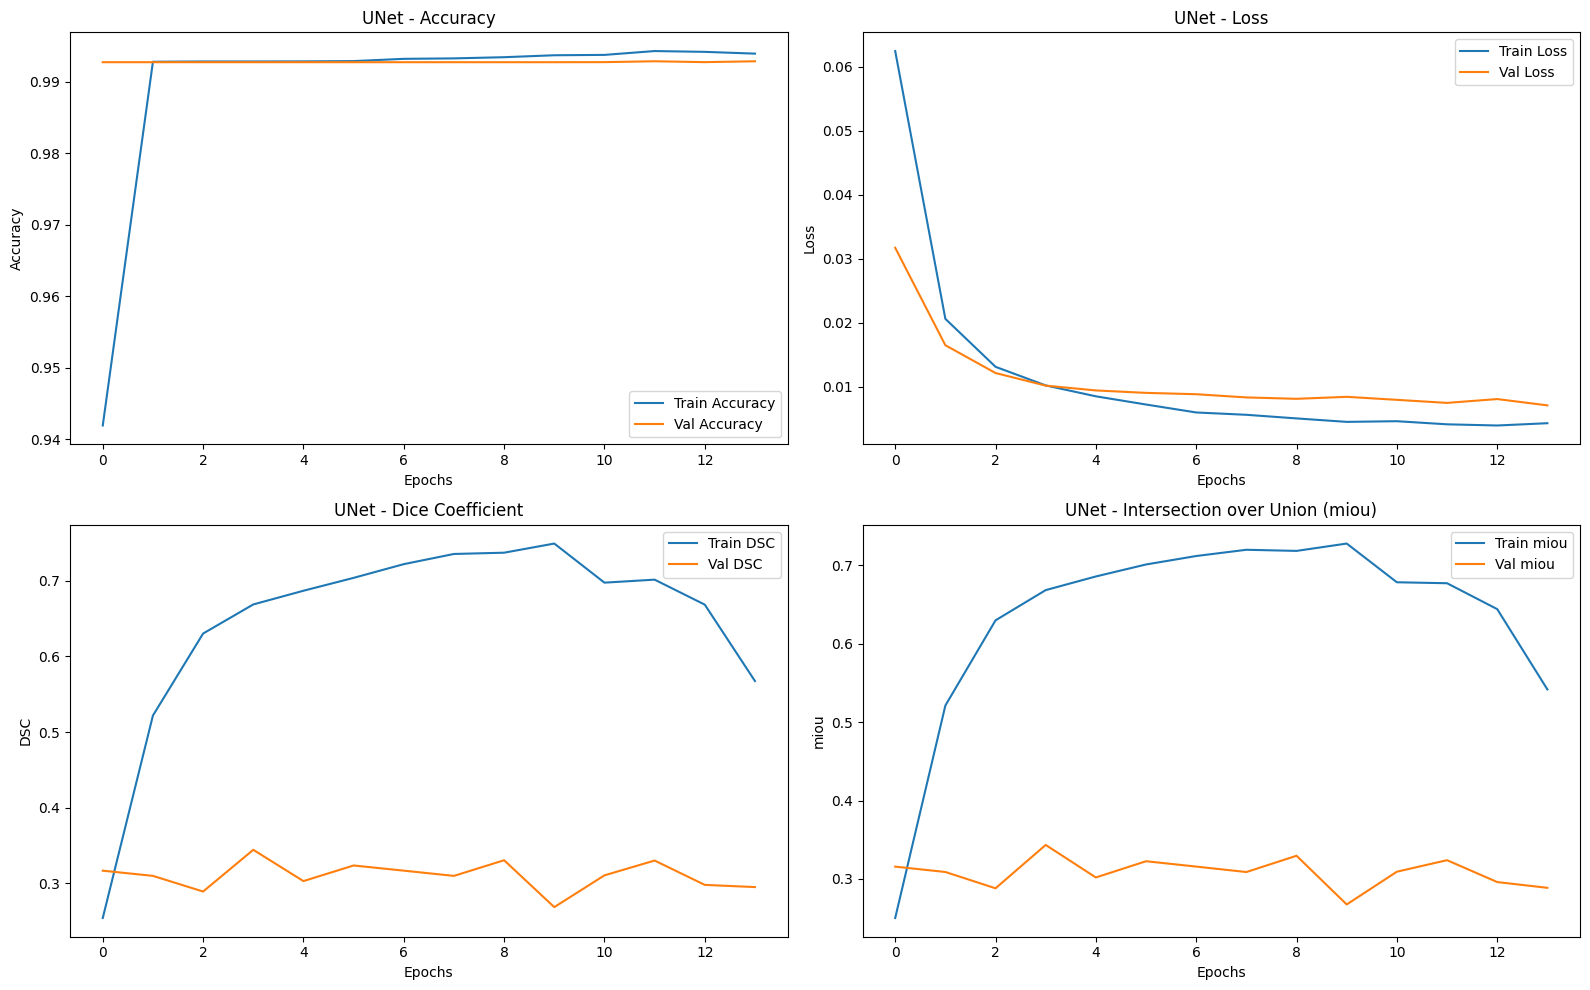

In [42]:
for history in [
                history_unet]: 
    plot_training_history(history, title=history.model.name)

# Testing

In [43]:
def mean_iou_per_class(model, dataset, num_classes=NUM_CLASSES):
    """
    Menghitung Mean IoU per kelas pada seluruh dataset.
    """
    total_intersection = np.zeros(num_classes)
    total_union = np.zeros(num_classes)

    for images, masks in dataset:
        preds = model.predict(images)
        y_pred = np.argmax(preds, axis=-1).reshape(-1)
        y_true = np.argmax(masks.numpy(), axis=-1).reshape(-1)  # or masks.numpy().reshape(-1) if already in int format
        for c in range(num_classes):
            true_c = (y_true == c)
            pred_c = (y_pred == c)
            intersection = np.logical_and(true_c, pred_c).sum()
            union = np.logical_or(true_c, pred_c).sum()
            total_intersection[c] += intersection
            total_union[c] += union

    mean_iou = np.divide(
        total_intersection,
        total_union,
        out=np.zeros_like(total_intersection, dtype=np.float32),
        where=total_union != 0
    )
    return mean_iou

In [44]:
results = model_unet.evaluate(test_ds)
print("Test loss:", results[0])
print("Test categorical_accuracyt:", results[1])
print("Test dice_coef:", results[2])
print("Test iou:", results[3])

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.9892 - dsc: 0.2616 - loss: 0.0132 - miou: 0.2605
Test loss: 0.013148202560842037
Test categorical_accuracyt: 0.9893013834953308
Test dice_coef: 0.25606533885002136
Test iou: 0.2550031542778015


In [45]:
CLASS_MAPPING = {
    0: 'Background',
    1: 'ablation',
    2: 'breakdown',
    3: 'fracture',
    4: 'groove'
}

In [46]:
# Contoh penggunaan:
miou_per_class = mean_iou_per_class(model_unet, test_ds, num_classes=NUM_CLASSES)
for idx, name in CLASS_MAPPING.items():
    print(f"Mean IoU for class '{name}': {miou_per_class[idx]:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(8, 256, 256, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Mean IoU for class 'Background': 0.9893
Mean IoU for class 'ablation': 0.0000
Mean IoU for class 'breakdown': 0.0000
Mean IoU for class 'fracture': 0.0000
Mean IoU for class 'groove': 0.0000


In [47]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model_and_plot_confusion(model, dataset, class_names):
    """
    Evaluasi model segmentasi:
    - Menampilkan test loss, accuracy, dice coef, dan mIoU
    - Menampilkan confusion matrix pixel-wise
    """

    # Hitung confusion matrix pixel-wise
    y_true_all, y_pred_all = [], []

    for images, masks in dataset:
        preds = model.predict(images)
        y_pred = np.argmax(preds, axis=-1).flatten()
        y_true = np.argmax(masks.numpy(), axis=-1).flatten()
        y_true_all.extend(y_true)
        y_pred_all.extend(y_pred)

    cm = confusion_matrix(y_true_all, y_pred_all, labels=range(len(class_names)))

    # Visualisasi confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (Pixel-wise)')
    plt.tight_layout()
    plt.show()
    
      # Evaluasi model
    print(classification_report(
        y_true_all, y_pred_all,
        target_names=class_names,
        zero_division=0
    ))
    

In [48]:
class_names = ['Background', 'ablation', 'breakdown', 'fracture', 'groove']

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


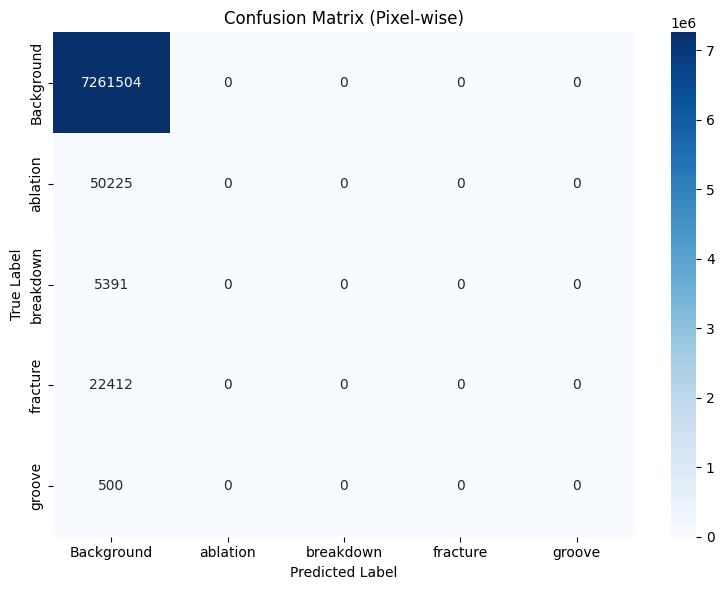

              precision    recall  f1-score   support

  Background       0.99      1.00      0.99   7261504
    ablation       0.00      0.00      0.00     50225
   breakdown       0.00      0.00      0.00      5391
    fracture       0.00      0.00      0.00     22412
      groove       0.00      0.00      0.00       500

    accuracy                           0.99   7340032
   macro avg       0.20      0.20      0.20   7340032
weighted avg       0.98      0.99      0.98   7340032



In [49]:
evaluate_model_and_plot_confusion(model_unet, test_ds, class_names)

# Visualisasi testing

In [ ]:
def overlay_mask_on_image(image, mask, class_names, alpha=0.5):
    """
    image: numpy array (H, W, 3), range [0, 1] or [0, 255]
    mask: numpy array (H, W), berisi index kelas (0=background, dst)
    class_names: list of str
    alpha: transparansi overlay
    """
    # Pastikan image dalam range [0, 1]
    if image.max() > 1.0:
        image = image / 255.0

    # Buat colormap
    cmap = plt.get_cmap('tab20', len(class_names))
    mask_rgb = cmap(mask)[..., :3]  # Ambil RGB saja

    # Overlay: background (0) tidak diwarnai
    mask_bool = mask > 0
    overlay = image.copy()
    overlay[mask_bool] = (1 - alpha) * image[mask_bool] + alpha * mask_rgb[mask_bool]
    return overlay

# Contoh penggunaan di fungsi predict_and_visualize:
def predict_and_visualize(model, image_path, input_size=(256, 256), class_names=None):
    img = load_img(image_path, target_size=input_size)
    img_array = img_to_array(img) / 255.0
    img_input = np.expand_dims(img_array, axis=0)

    pred_mask = model.predict(img_input)[0]  # shape: (H, W, C)
    mask_argmax = np.argmax(pred_mask, axis=-1)  # shape: (H, W)

    plt.figure(figsize=(18, 6))

    # Gambar asli
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis("off")

    # Mask prediksi
    plt.subplot(1, 3, 2)
    if class_names is None:
        class_names = [f"Class {i}" for i in range(pred_mask.shape[-1])]
    cmap = plt.get_cmap('tab20', len(class_names))
    im = plt.imshow(mask_argmax, cmap=cmap, vmin=0, vmax=len(class_names)-1)
    plt.title("Predicted Mask")
    plt.axis("off")
    cbar = plt.colorbar(im, ticks=range(len(class_names)), fraction=0.046, pad=0.04)
    cbar.ax.set_yticklabels(class_names)
    plt.clim(-0.5, len(class_names)-0.5)

    # Overlay
    plt.subplot(1, 3, 3)
    overlay = overlay_mask_on_image(img_array, mask_argmax, class_names, alpha=0.5)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Overlay mask ke atas gambar asli
def overlay_mask_on_image(image, mask, class_names, alpha=0.5):
    if image.max() > 1.0:
        image = image / 255.0

    cmap = plt.get_cmap('tab20', len(class_names))
    mask_rgb = cmap(mask)[..., :3]

    mask_bool = mask > 0
    overlay = image.copy()
    overlay[mask_bool] = (1 - alpha) * image[mask_bool] + alpha * mask_rgb[mask_bool]
    return overlay

# Visualisasi image + mask (true), pred mask, image + pred mask
def visualize_segmentation(image_array, pred_mask, true_mask=None, class_names=None):
    if class_names is None:
        num_classes = pred_mask.max() + 1 if true_mask is None else max(pred_mask.max(), true_mask.max()) + 1
        class_names = [f"Class {i}" for i in range(num_classes)]

    cmap = plt.get_cmap('tab20', len(class_names))
    ncols = 3 if true_mask is not None else 2
    plt.figure(figsize=(6 * ncols, 6))

    if true_mask is not None:
        plt.subplot(1, ncols, 1)
        overlay_true = overlay_mask_on_image(image_array, true_mask, class_names, alpha=0.5)
        plt.imshow(overlay_true)
        plt.title("Image + True Mask")
        plt.axis("off")
        idx = 2
    else:
        idx = 1

    plt.subplot(1, ncols, idx)
    im = plt.imshow(pred_mask, cmap=cmap, vmin=0, vmax=len(class_names)-1)
    plt.title("Predicted Mask")
    plt.axis("off")
    cbar = plt.colorbar(im, ticks=range(len(class_names)), fraction=0.046, pad=0.04)
    cbar.ax.set_yticklabels(class_names)
    plt.clim(-0.5, len(class_names)-0.5)

    plt.subplot(1, ncols, idx + 1)
    overlay_pred = overlay_mask_on_image(image_array, pred_mask, class_names, alpha=0.5)
    plt.imshow(overlay_pred)
    plt.title("Image + Predicted Mask")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# Prediksi dan visualisasi
def predict_and_visualize(model, image_path, input_size=(256, 256), class_names=None, true_mask=None):
    img = load_img(image_path, target_size=input_size)
    img_array = img_to_array(img) / 255.0
    img_input = np.expand_dims(img_array, axis=0)

    pred_mask = model.predict(img_input)[0]  # (H, W, C)
    pred_classes = np.argmax(pred_mask, axis=-1)  # (H, W)

    visualize_segmentation(img_array, pred_classes, true_mask=true_mask, class_names=class_names)

In [ ]:
CLASS_NAMES

In [ ]:
def load_true_mask(mask_path, target_size):
    mask = load_img(mask_path, target_size=target_size, color_mode="grayscale")
    mask_array = img_to_array(mask).squeeze().astype(np.uint8)  # shape: (H, W)
    return mask_array

# Direktori image dan mask
image_dir = f"{ROOT_DIR}/test/images"
mask_dir = f"{ROOT_DIR}/test/masks"

for img_file in os.listdir(image_dir):
    if img_file.endswith(".jpg") or img_file.endswith(".png"):
        img_path = os.path.join(image_dir, img_file)

        # Ganti ekstensi ke .png jika mask disimpan dalam .png
        mask_file = os.path.splitext(img_file)[0] + ".png"
        mask_path = os.path.join(mask_dir, mask_file)

        # Cek apakah file mask ada
        if os.path.exists(mask_path):
            true_mask = load_true_mask(mask_path, target_size=(256, 256))
        else:
            print(f"WARNING: Mask not found for {img_file}, skipping true mask overlay.")
            true_mask = None

        print(f"Processing: {img_file}")
        predict_and_visualize(model_resnet_transunet, img_path, input_size=(256, 256),
                              class_names=CLASS_NAMES, true_mask=true_mask)
